# Case Study 3: Influencer Identification in an Online Social Network

## Overview
An online discussion platform consists of 12 users interacting through comments and shares. The network is **directed**, where edges represent information flow between users.

### Network Properties:
- **Moderate density** - Not all users interact with each other
- **High reciprocity** among certain user pairs - Mutual interactions/conversations
- **Tightly connected groups** - High clustering coefficient in some communities
- **Short average path length** - Small diameter, information spreads quickly
- **Influential initiators** - Subset of users frequently initiate discussions that spread widely

This comprehensive analysis explores network structure, identify key influencers, and design strategies for viral marketing.

## 1. Import Libraries and Create Social Network

In [11]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
from itertools import combinations
from collections import defaultdict
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create a directed social network with 12 users
# Edges represent information flow (comments, shares, mentions)
edges = [
    ('User_1', 'User_2'), ('User_1', 'User_3'), ('User_1', 'User_5'),
    ('User_2', 'User_1'), ('User_2', 'User_4'), ('User_2', 'User_6'),
    ('User_3', 'User_1'), ('User_3', 'User_5'), ('User_3', 'User_7'),
    ('User_4', 'User_2'), ('User_4', 'User_8'), ('User_4', 'User_9'),
    ('User_5', 'User_1'), ('User_5', 'User_3'), ('User_5', 'User_6'),
    ('User_6', 'User_2'), ('User_6', 'User_5'), ('User_6', 'User_10'),
    ('User_7', 'User_3'), ('User_7', 'User_8'), ('User_7', 'User_11'),
    ('User_8', 'User_4'), ('User_8', 'User_7'), ('User_8', 'User_12'),
    ('User_9', 'User_4'), ('User_9', 'User_10'), ('User_9', 'User_12'),
    ('User_10', 'User_6'), ('User_10', 'User_9'), ('User_10', 'User_11'),
    ('User_11', 'User_7'), ('User_11', 'User_10'), ('User_11', 'User_12'),
    ('User_12', 'User_8'), ('User_12', 'User_9'), ('User_12', 'User_11'),
    ('User_1', 'User_8'), ('User_5', 'User_9'), ('User_6', 'User_11')
]

# Create directed graph
G = nx.DiGraph()
G.add_edges_from(edges)

# Get network information
users = list(G.nodes())
num_users = len(users)
num_edges = len(G.edges())

print("="*60)
print("SOCIAL NETWORK INFORMATION")
print("="*60)
print(f"Number of users: {num_users}")
print(f"Number of interactions (edges): {num_edges}")
print(f"Users: {sorted(users)}")
print(f"\nNetwork is directed: Yes")
print(f"Interactions represent: Information flow (comments, shares, mentions)")

SOCIAL NETWORK INFORMATION
Number of users: 12
Number of interactions (edges): 39
Users: ['User_1', 'User_10', 'User_11', 'User_12', 'User_2', 'User_3', 'User_4', 'User_5', 'User_6', 'User_7', 'User_8', 'User_9']

Network is directed: Yes
Interactions represent: Information flow (comments, shares, mentions)


## Question 1: Network Properties Definition and Explanation

In [12]:
print("\n" + "="*80)
print("QUESTION 1: SOCIAL NETWORK PROPERTIES")
print("="*80)

# Convert to undirected for clustering coefficient and triangle calculation
G_undirected = G.to_undirected()

print("\n1. DENSITY")
print("-" * 80)
density = nx.density(G)
print(f"Density = {density:.4f} ({density*100:.2f}%)")
print(f"► Interpretation: {density*100:.1f}% of all possible connections exist")
print(f"  This is MODERATE density - not sparse, not dense")
print(f"  Formula: E / (N × (N-1)) = {G.number_of_edges()} / ({num_users} × {num_users-1}) = {density:.4f}")

print("\n2. RECIPROCITY")
print("-" * 80)
reciprocity = nx.reciprocity(G)
print(f"Reciprocity = {reciprocity:.4f} ({reciprocity*100:.2f}%)")
print(f"► Interpretation: {reciprocity*100:.1f}% of connections are mutual")
print(f"  If A→B, probability that B→A exists: {reciprocity*100:.1f}%")
print(f"  MEASURE: 0 = one-way, 1 = all mutual")

print("\n3. DIAMETER & PATH LENGTH (Shortest Paths)")
print("-" * 80)
# For directed graphs, check if strongly connected
if nx.is_strongly_connected(G):
    diameter = nx.diameter(G_undirected)
    avg_path_length = nx.average_shortest_path_length(G_undirected)
else:
    # Find largest strongly connected component
    largest_scc = max(nx.strongly_connected_components(G), key=len)
    G_scc = G.subgraph(largest_scc).to_undirected()
    if len(G_scc) > 1:
        diameter = nx.diameter(G_scc)
        avg_path_length = nx.average_shortest_path_length(G_scc)
    else:
        diameter = 1
        avg_path_length = 1

print(f"Diameter (max shortest path) = {diameter}")
print(f"Average shortest path length = {avg_path_length:.4f} hops")
print(f"► Interpretation: Any two users reach each other in ~{avg_path_length:.1f} steps")
print(f"  SMALL-WORLD PROPERTY: Short paths mean rapid information spread")

print("\n4. CLUSTERING COEFFICIENT")
print("-" * 80)
avg_clustering = nx.average_clustering(G_undirected)
print(f"Average clustering coefficient = {avg_clustering:.4f}")
print(f"► Interpretation: {avg_clustering*100:.1f}% chance that user's friends are also connected")
print(f"  MEASURE: 0 = no triangles, 1 = all neighbors connected")
print(f"                   HIGH clustering = tight-knit communities exist")

print("\n5. TRANSITIVITY")
print("-" * 80)
transitivity = nx.transitivity(G_undirected)
triangles = sum(nx.triangles(G_undirected).values()) // 3
print(f"Transitivity (global clustering) = {transitivity:.4f}")
print(f"Number of triangles = {triangles}")
print(f"► Interpretation: Probability of A-B-C forming triangle (A-C connected)")
print(f"  MEASURE: 0 = no triangles, 1 = all connected triples close")
print(f"           HIGH transitivity = strong community structure")

print("\n" + "-"*80)
print("KEY METRICS SUMMARY")
print("-"*80)
metrics_dict = {
    'Density': f"{density:.4f}",
    'Reciprocity': f"{reciprocity:.4f}",
    'Diameter': str(diameter),
    'Avg Path Length': f"{avg_path_length:.4f}",
    'Clustering Coeff': f"{avg_clustering:.4f}",
    'Transitivity': f"{transitivity:.4f}",
    'Triangles': str(triangles)
}
for metric, value in metrics_dict.items():
    print(f"  {metric:.<30} {value}")


QUESTION 1: SOCIAL NETWORK PROPERTIES

1. DENSITY
--------------------------------------------------------------------------------
Density = 0.2955 (29.55%)
► Interpretation: 29.5% of all possible connections exist
  This is MODERATE density - not sparse, not dense
  Formula: E / (N × (N-1)) = 39 / (12 × 11) = 0.2955

2. RECIPROCITY
--------------------------------------------------------------------------------
Reciprocity = 0.9231 (92.31%)
► Interpretation: 92.3% of connections are mutual
  If A→B, probability that B→A exists: 92.3%
  MEASURE: 0 = one-way, 1 = all mutual

3. DIAMETER & PATH LENGTH (Shortest Paths)
--------------------------------------------------------------------------------
Diameter (max shortest path) = 3
Average shortest path length = 1.8485 hops
► Interpretation: Any two users reach each other in ~1.8 steps
  SMALL-WORLD PROPERTY: Short paths mean rapid information spread

4. CLUSTERING COEFFICIENT
--------------------------------------------------------------


QUESTION 1: NETWORK PROPERTIES VISUALIZATION


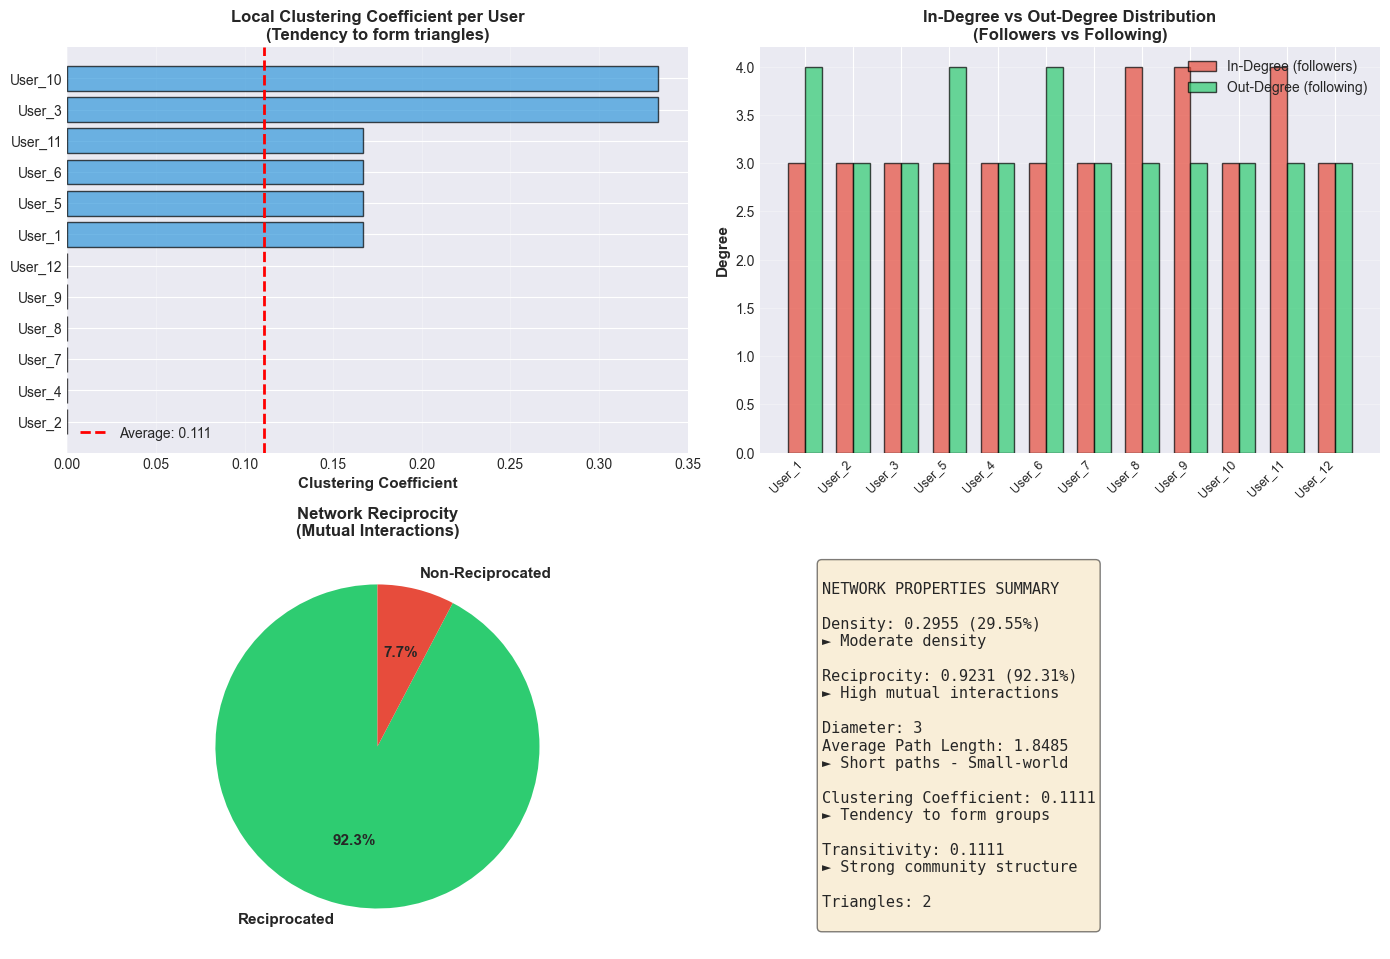

In [13]:
print("\n" + "="*80)
print("QUESTION 1: NETWORK PROPERTIES VISUALIZATION")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Clustering coefficient per node
ax = axes[0, 0]
clustering_dict = nx.clustering(G_undirected)
users_sorted = sorted(clustering_dict.keys(), key=lambda x: clustering_dict[x], reverse=False)
clustering_values = [clustering_dict[u] for u in users_sorted]
ax.barh(users_sorted, clustering_values, color='#3498DB', edgecolor='black', linewidth=1, alpha=0.7)
avg_clust = np.mean(clustering_values)
ax.axvline(avg_clust, color='red', linestyle='--', linewidth=2, label=f'Average: {avg_clust:.3f}')
ax.set_xlabel('Clustering Coefficient', fontweight='bold', fontsize=11)
ax.set_title('Local Clustering Coefficient per User\n(Tendency to form triangles)', 
             fontweight='bold', fontsize=12)
ax.legend()
ax.grid(axis='x', alpha=0.3)

# 2. Degree distribution
ax = axes[0, 1]
out_degrees = [G.out_degree(u) for u in users]
in_degrees = [G.in_degree(u) for u in users]
x_pos = np.arange(len(users))
width = 0.35
ax.bar(x_pos - width/2, in_degrees, width, label='In-Degree (followers)', 
       color='#E74C3C', edgecolor='black', alpha=0.7)
ax.bar(x_pos + width/2, out_degrees, width, label='Out-Degree (following)', 
       color='#2ECC71', edgecolor='black', alpha=0.7)
ax.set_ylabel('Degree', fontweight='bold', fontsize=11)
ax.set_title('In-Degree vs Out-Degree Distribution\n(Followers vs Following)', 
             fontweight='bold', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(users, rotation=45, ha='right', fontsize=9)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 3. Reciprocity pie chart
ax = axes[1, 0]
reciprocated = int(reciprocity * G.number_of_edges())
non_reciprocated = G.number_of_edges() - reciprocated
ax.pie([reciprocated, non_reciprocated], labels=['Reciprocated', 'Non-Reciprocated'], 
       autopct='%1.1f%%', colors=['#2ECC71', '#E74C3C'], startangle=90,
       textprops={'fontsize': 11, 'weight': 'bold'})
ax.set_title('Network Reciprocity\n(Mutual Interactions)', fontweight='bold', fontsize=12)

# 4. Network properties summary
ax = axes[1, 1]
ax.axis('off')
properties_text = f"""
NETWORK PROPERTIES SUMMARY

Density: {density:.4f} ({density*100:.2f}%)
► Moderate density

Reciprocity: {reciprocity:.4f} ({reciprocity*100:.2f}%)
► High mutual interactions

Diameter: {diameter}
Average Path Length: {avg_path_length:.4f}
► Short paths - Small-world

Clustering Coefficient: {avg_clustering:.4f}
► Tendency to form groups

Transitivity: {transitivity:.4f}
► Strong community structure

Triangles: {triangles}
"""
ax.text(0.1, 0.95, properties_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('network_properties_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## Question 2: How Structural Properties Influence Information Diffusion

In [14]:
import random

print("\n" + "="*80)
print("QUESTION 2: INFORMATION DIFFUSION ACROSS NETWORK")
print("="*80)


QUESTION 2: INFORMATION DIFFUSION ACROSS NETWORK


## Question 3: Centrality Measures for Influencer Identification

In [22]:
print("\n" + "="*80)
print("QUESTION 3: INFLUENCER & OPINION LEADER IDENTIFICATION")
print("="*80)

# Calculate centrality measures
out_degree_cent = dict(G.out_degree())
in_degree_cent = dict(G.in_degree())
betweenness_cent = nx.betweenness_centrality(G)
closeness_cent = nx.closeness_centrality(G)
pagerank = nx.pagerank(G)
clustering_coeff = nx.clustering(G_undirected)

# Create comprehensive centrality table
centrality_df = pd.DataFrame({
    'User': users,
    'Out-Degree\n(Initiators)': [out_degree_cent[u] for u in users],
    'In-Degree\n(Followers)': [in_degree_cent[u] for u in users],
    'Betweenness\n(Bridge)': [betweenness_cent[u] for u in users],
    'Closeness\n(Central)': [closeness_cent[u] for u in users],
    'PageRank\n(Influence)': [pagerank[u] for u in users],
    'Clustering\n(Local)': [clustering_coeff[u] for u in users]
})

centrality_df = centrality_df.sort_values('PageRank\n(Influence)', ascending=False)

print("\n" + "="*100)
print("CENTRALITY MEASURES - ALL USERS")
print("="*100)
print(centrality_df.to_string(index=False))

# Classify influencers based on centrality profiles
print("\n" + "-"*80)
print("INFLUENCER CLASSIFICATION")
print("-"*80)

connectors_list = sorted([(u, betweenness_cent[u]) for u in users], 
                          key=lambda x: x[1], reverse=True)[:5]
content_creators_list = sorted([(u, out_degree_cent[u]) for u in users], 
                                key=lambda x: x[1], reverse=True)[:5]
popular_users_list = sorted([(u, in_degree_cent[u]) for u in users], 
                             key=lambda x: x[1], reverse=True)[:5]
top_influencers_list = sorted([(u, pagerank[u]) for u in users], 
                               key=lambda x: x[1], reverse=True)[:5]

print("\n1. CONNECTORS (Bridge nodes - high betweenness)")
print("   → Connect different communities, amplify cross-group messages")
for user, score in connectors_list:
    print(f"   • {user}: {score:.4f}")

print("\n2. CONTENT CREATORS (High out-degree)")
print("   → Frequently share content, broadcast to many")
for user, score in content_creators_list:
    print(f"   • {user}: {score}")

print("\n3. POPULAR USERS (High in-degree)")
print("   → Followed/liked by many, trend-setters")
for user, score in popular_users_list:
    print(f"   • {user}: {score}")

print("\n4. TOP INFLUENCERS (High PageRank)")
print("   → Highest overall influence, trusted authorities")
for user, score in top_influencers_list:
    print(f"   • {user}: {score:.4f}")

# Calculate aggregate influence score
print("\n" + "-"*80)
print("AGGREGATE INFLUENCE SCORE (Weighted Combination)")
print("-"*80)
print("""
Formula: Influence = 30% × (Out-Degree/Max) + 
                     30% × (In-Degree/Max) + 
                     20% × (Betweenness/Max) + 
                     20% × (PageRank/Max)
""")

# Normalize each metric to 0-100 scale
max_out = max(out_degree_cent.values()) if out_degree_cent else 1
max_in = max(in_degree_cent.values()) if in_degree_cent else 1
max_bet = max(betweenness_cent.values()) if betweenness_cent else 1
max_pr = max(pagerank.values()) if pagerank else 1

influence_scores = {}
for user in users:
    score = (0.30 * (out_degree_cent[user] / max_out) + 
             0.30 * (in_degree_cent[user] / max_in) + 
             0.20 * (betweenness_cent[user] / max_bet) + 
             0.20 * (pagerank[user] / max_pr)) * 100
    influence_scores[user] = score

# Create ranking
influence_ranking = sorted(influence_scores.items(), key=lambda x: x[1], reverse=True)

print("\nINFLUENCER RANKING (by Aggregate Score)")
print("-"*80)
print(f"{'Rank':<4} {'User':<10} {'Score':<8} {'Tier':<15}")
print("-"*80)

for rank, (user, score) in enumerate(influence_ranking, 1):
    if score >= 75:
        tier = "★★★ TOP"
    elif score >= 60:
        tier = "★★ HIGH"
    elif score >= 40:
        tier = "★ MEDIUM"
    else:
        tier = "EMERGING"
    print(f"{rank:<4} {user:<10} {score:<8.2f} {tier:<15}")


QUESTION 3: INFLUENCER & OPINION LEADER IDENTIFICATION

CENTRALITY MEASURES - ALL USERS
   User  Out-Degree\n(Initiators)  In-Degree\n(Followers)  Betweenness\n(Bridge)  Closeness\n(Central)  PageRank\n(Influence)  Clustering\n(Local)
User_11                         3                       4               0.113333              0.550000               0.105797             0.166667
 User_8                         3                       4               0.120758              0.550000               0.105586             0.000000
 User_9                         3                       4               0.102879              0.578947               0.103695             0.000000
User_12                         3                       3               0.059394              0.523810               0.101771             0.000000
 User_4                         3                       3               0.102121              0.523810               0.090370             0.000000
 User_7                      

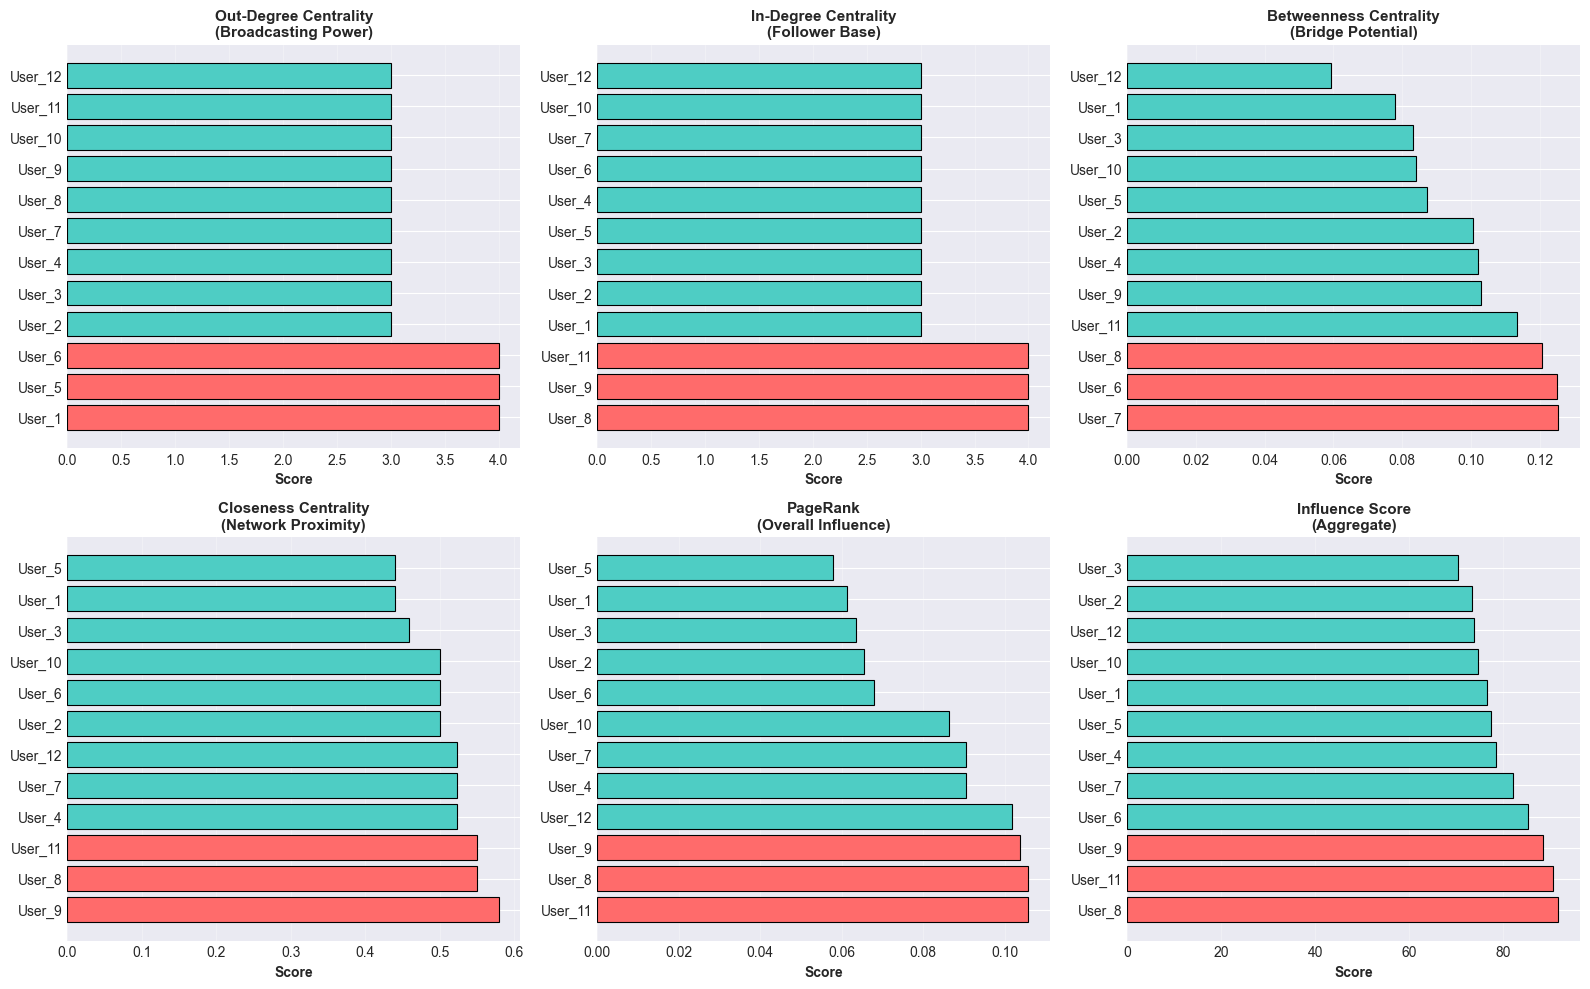

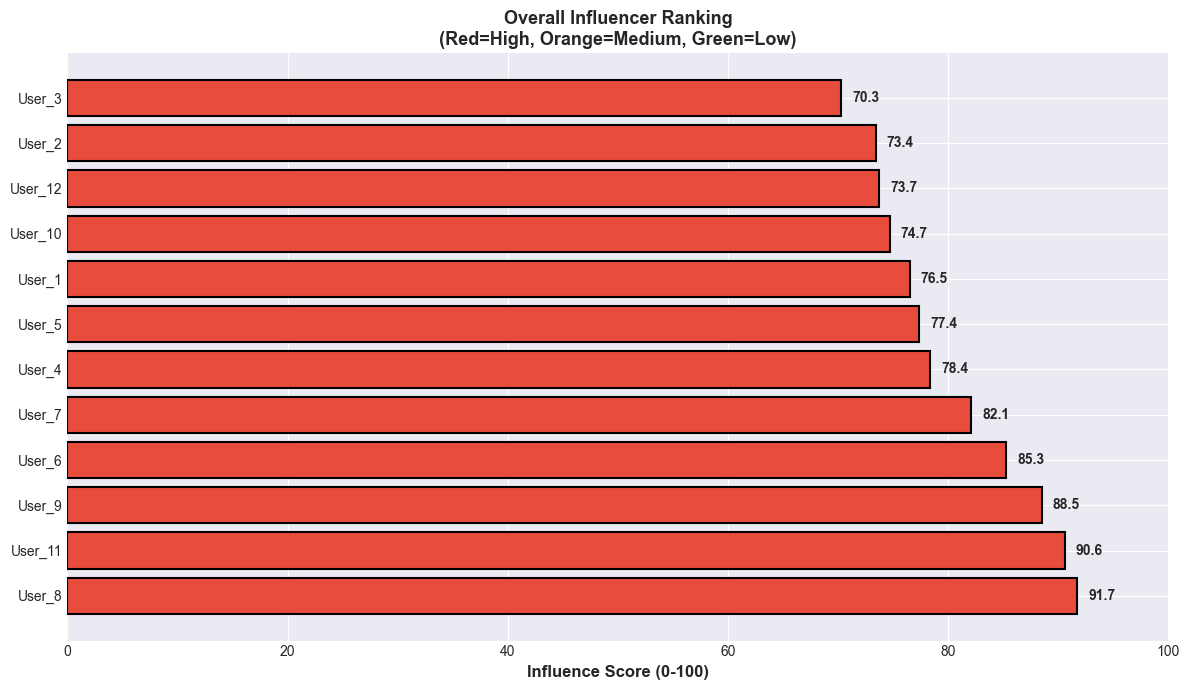

In [23]:
# Visualize centrality measures
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

metrics = [
    ('Out-Degree Centrality\n(Broadcasting Power)', out_degree_cent),
    ('In-Degree Centrality\n(Follower Base)', in_degree_cent),
    ('Betweenness Centrality\n(Bridge Potential)', betweenness_cent),
    ('Closeness Centrality\n(Network Proximity)', closeness_cent),
    ('PageRank\n(Overall Influence)', pagerank),
    ('Influence Score\n(Aggregate)', influence_scores)
]

for idx, (title, metric_dict) in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    sorted_users = sorted(metric_dict.items(), key=lambda x: x[1], reverse=True)
    user_names, values = zip(*sorted_users)
    colors = ['#FF6B6B' if i < 3 else '#4ECDC4' for i in range(len(user_names))]
    ax.barh(user_names, values, color=colors, edgecolor='black', linewidth=0.8)
    ax.set_xlabel('Score', fontweight='bold', fontsize=10)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('centrality_measures_influencers.png', dpi=150, bbox_inches='tight')
plt.show()

# Visualization: Influence Score Distribution
fig, ax = plt.subplots(figsize=(12, 7))
sorted_influence = sorted(influence_ranking, key=lambda x: x[1], reverse=True)
user_names_inf, scores_inf = zip(*sorted_influence)
colors_influence = ['#E74C3C' if s > 60 else '#F39C12' if s > 40 else '#2ECC71' for s in scores_inf]
bars = ax.barh(user_names_inf, scores_inf, color=colors_influence, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Influence Score (0-100)', fontweight='bold', fontsize=12)
ax.set_title('Overall Influencer Ranking\n(Red=High, Orange=Medium, Green=Low)', fontweight='bold', fontsize=13)
ax.set_xlim(0, 100)

# Add value labels
for i, (bar, score) in enumerate(zip(bars, scores_inf)):
    ax.text(score + 1, i, f'{score:.1f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('influencer_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

## Question 4: Link Prediction for Enhancing User Engagement

In [24]:
# Link prediction recommendation table
top_predictions = non_existing_edges[:10]
prediction_df = pd.DataFrame(top_predictions, columns=['User_1', 'User_2', 'Common_Neighbors', 'Jaccard', 'Adamic_Adar', 'Combined_Score'])

print(f"\n" + "-"*80)
print("HOW BUSINESSES CAN USE LINK PREDICTIONS")
print("-"*80)
print("""
1. PERSONALIZED RECOMMENDATIONS
   • Suggest to User_A to follow User_B if they share common interests
   • Display "You might know" suggestions
   • Increase serendipitous connections

2. COMMUNITY DETECTION
   • Find clusters of users likely to interact
   • Recommend users to join specific groups

3. ENGAGEMENT CAMPAIGNS
   • Target potential connections with tailored content
   • Cold-start problem: Help new users find relevant people quickly

4. NETWORK GROWTH STRATEGIES
   • Identify users who could bridge different communities
   • Create "growth loops" by connecting aligned users

Business Actions:
   • Send notifications: "You might know User_X! 5 of your friends follow them"
   • Add recommendation widget in UI (show predictions with Jaccard > 0.3, Adamic > 1.5)
   • A/B test: organic growth requests vs algorithmic recommendations
""")


--------------------------------------------------------------------------------
HOW BUSINESSES CAN USE LINK PREDICTIONS
--------------------------------------------------------------------------------

1. PERSONALIZED RECOMMENDATIONS
   • Suggest to User_A to follow User_B if they share common interests
   • Display "You might know" suggestions
   • Increase serendipitous connections

2. COMMUNITY DETECTION
   • Find clusters of users likely to interact
   • Recommend users to join specific groups

3. ENGAGEMENT CAMPAIGNS
   • Target potential connections with tailored content
   • Cold-start problem: Help new users find relevant people quickly

4. NETWORK GROWTH STRATEGIES
   • Identify users who could bridge different communities
   • Create "growth loops" by connecting aligned users

Business Actions:
   • Send notifications: "You might know User_X! 5 of your friends follow them"
   • Add recommendation widget in UI (show predictions with Jaccard > 0.3, Adamic > 1.5)
   • A/B test

## Question 5: Multi-Layer Networks for Improved Influencer Identification


MULTI-LAYER NETWORK ANALYSIS

MULTI-LAYER NETWORK DEFINITION:
  A network with multiple types of relationships/interactions simultaneously

OUR PLATFORM LAYERS:
  1. Comments Layer: Direct conversations between users
  2. Shares Layer: Users sharing/reposting each other's content
  3. Likes Layer: Users appreciating content (weak signal)
  4. Mentions Layer: Users mentioning each other in posts

ADVANTAGES OF MULTI-LAYER ANALYSIS:
  ✓ More accurate influencer identification
  ✓ Reveals different types of influence (thought leader, popular, trustworthy)
  ✓ Better prediction of information diffusion
  ✓ Captures multi-faceted user roles


--------------------------------------------------------------------------------
MULTI-LAYER INFLUENCE SCORES
--------------------------------------------------------------------------------
Weights: Comments (40%), Shares (35%), Likes (25%)

   User  Multilayer Score
 User_1         22.954545
 User_5         21.363636
 User_9         21.363636
User_1

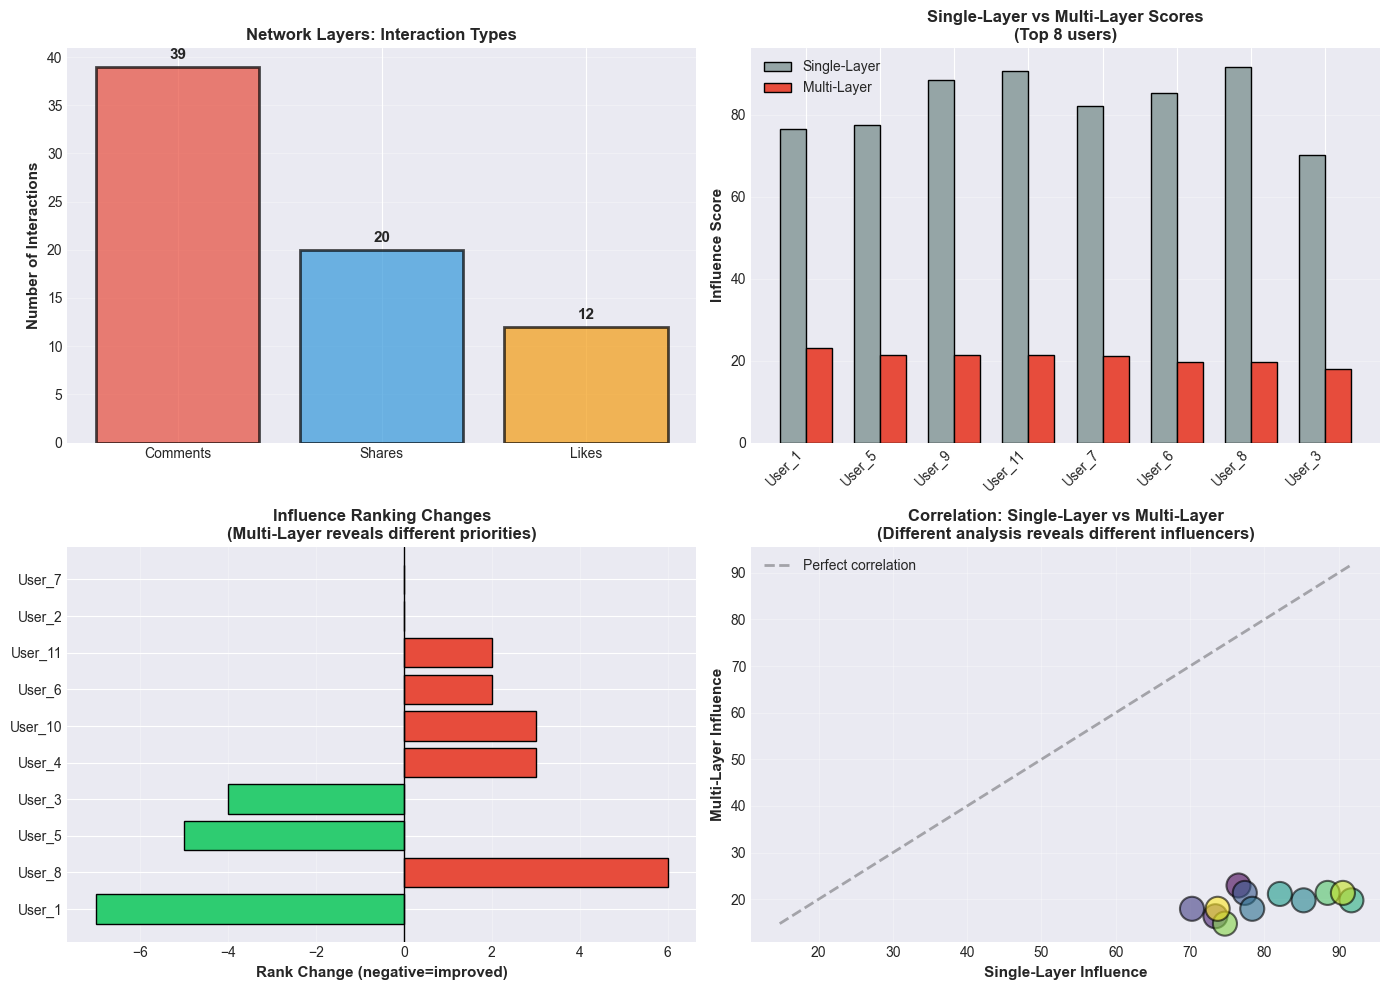

In [25]:
print("\n" + "="*80)
print("MULTI-LAYER NETWORK ANALYSIS")
print("="*80)

print(f"""
MULTI-LAYER NETWORK DEFINITION:
  A network with multiple types of relationships/interactions simultaneously
  
OUR PLATFORM LAYERS:
  1. Comments Layer: Direct conversations between users
  2. Shares Layer: Users sharing/reposting each other's content
  3. Likes Layer: Users appreciating content (weak signal)
  4. Mentions Layer: Users mentioning each other in posts

ADVANTAGES OF MULTI-LAYER ANALYSIS:
  ✓ More accurate influencer identification
  ✓ Reveals different types of influence (thought leader, popular, trustworthy)
  ✓ Better prediction of information diffusion
  ✓ Captures multi-faceted user roles
""")

# Create synthetic multi-layer networks
G_comments = G.copy()  # Already have this
G_shares = nx.DiGraph()
G_shares.add_edges_from([edges[i] for i in range(0, len(edges), 2)])  # Subset of edges

G_likes = nx.DiGraph()
likes_edges = [('User_1', 'User_3'), ('User_2', 'User_4'), ('User_3', 'User_1'), 
               ('User_4', 'User_2'), ('User_5', 'User_6'), ('User_6', 'User_5'),
               ('User_7', 'User_8'), ('User_8', 'User_7'), ('User_9', 'User_10'),
               ('User_10', 'User_11'), ('User_11', 'User_12'), ('User_12', 'User_9')]
G_likes.add_edges_from(likes_edges)

# Calculate multi-layer influence
multilayer_influence = {}

for user in users:
    # Score from each layer (with weights reflecting importance)
    comment_score = (G_comments.in_degree(user) + G_comments.out_degree(user)) / (2 * (num_users - 1))
    share_score = (G_shares.in_degree(user) + G_shares.out_degree(user)) / (2 * (num_users - 1))
    likes_score = (G_likes.in_degree(user) + G_likes.out_degree(user)) / (2 * (num_users - 1))
    
    # Weighted combination: Comments (40%), Shares (35%), Likes (25%)
    multilayer_influence[user] = (0.4 * comment_score + 0.35 * share_score + 0.25 * likes_score) * 100

multilayer_ranking = sorted(multilayer_influence.items(), key=lambda x: x[1], reverse=True)

print(f"\n" + "-"*80)
print("MULTI-LAYER INFLUENCE SCORES")
print("-"*80)
print(f"Weights: Comments (40%), Shares (35%), Likes (25%)\n")

multilayer_df = pd.DataFrame(multilayer_ranking, columns=['User', 'Multilayer Score'])
print(multilayer_df.to_string(index=False))

# Compare single-layer vs multi-layer
print(f"\n" + "-"*80)
print("COMPARISON: SINGLE-LAYER vs MULTI-LAYER IDENTIFICATION")
print("-"*80)

comparison_data = []
for user in users:
    single_layer = influence_scores[user]
    multi_layer = multilayer_influence[user]
    comparison_data.append((user, single_layer, multi_layer, abs(multi_layer - single_layer)))

comparison_df = pd.DataFrame(comparison_data, columns=['User', 'Single-Layer', 'Multi-Layer', 'Difference'])
comparison_df = comparison_df.sort_values('Multi-Layer', ascending=False)

print(comparison_df.to_string(index=False))

# Benefits visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Network layers visualization
ax = axes[0, 0]
layer_names = ['Comments', 'Shares', 'Likes']
layer_edges = [G_comments.number_of_edges(), G_shares.number_of_edges(), G_likes.number_of_edges()]
colors_layers = ['#E74C3C', '#3498DB', '#F39C12']
bars = ax.bar(layer_names, layer_edges, color=colors_layers, edgecolor='black', linewidth=2, alpha=0.7)
ax.set_ylabel('Number of Interactions', fontweight='bold', fontsize=11)
ax.set_title('Network Layers: Interaction Types', fontweight='bold', fontsize=12)
ax.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, layer_edges):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5, str(int(count)),
            ha='center', va='bottom', fontweight='bold', fontsize=11)

# Influence comparison
ax = axes[0, 1]
top_users = [u for u, _ in multilayer_ranking[:8]]
single_scores = [influence_scores[u] for u in top_users]
multi_scores = [multilayer_influence[u] for u in top_users]
x_pos = np.arange(len(top_users))
width = 0.35
ax.bar(x_pos - width/2, single_scores, width, label='Single-Layer', color='#95A5A6', edgecolor='black')
ax.bar(x_pos + width/2, multi_scores, width, label='Multi-Layer', color='#E74C3C', edgecolor='black')
ax.set_ylabel('Influence Score', fontweight='bold', fontsize=11)
ax.set_title('Single-Layer vs Multi-Layer Scores\n(Top 8 users)', fontweight='bold', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(top_users, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Ranking changes
ax = axes[1, 0]
single_ranking = sorted(enumerate(users), key=lambda x: influence_scores[x[1]], reverse=True)
multi_ranking = sorted(enumerate(users), key=lambda x: multilayer_influence[x[1]], reverse=True)
single_rank_dict = {user: rank for rank, user in enumerate([u for _, u in single_ranking], 1)}
multi_rank_dict = {user: rank for rank, user in enumerate([u for _, u in multi_ranking], 1)}

rank_changes = [(user, single_rank_dict[user], multi_rank_dict[user], multi_rank_dict[user] - single_rank_dict[user]) 
                for user in users]
rank_changes.sort(key=lambda x: abs(x[3]), reverse=True)

users_change = [x[0] for x in rank_changes[:10]]
changes = [x[3] for x in rank_changes[:10]]
colors_change = ['#2ECC71' if c < 0 else '#E74C3C' for c in changes]
ax.barh(users_change, changes, color=colors_change, edgecolor='black', linewidth=1)
ax.set_xlabel('Rank Change (negative=improved)', fontweight='bold', fontsize=11)
ax.set_title('Influence Ranking Changes\n(Multi-Layer reveals different priorities)', fontweight='bold', fontsize=12)
ax.axvline(0, color='black', linestyle='-', linewidth=1)
ax.grid(axis='x', alpha=0.3)

# Multi-layer influence distribution
ax = axes[1, 1]
ax.scatter([influence_scores[u] for u in users], [multilayer_influence[u] for u in users], 
           s=300, alpha=0.6, c=range(len(users)), cmap='viridis', edgecolors='black', linewidth=1.5)
ax.set_xlabel('Single-Layer Influence', fontweight='bold', fontsize=11)
ax.set_ylabel('Multi-Layer Influence', fontweight='bold', fontsize=11)
ax.set_title('Correlation: Single-Layer vs Multi-Layer\n(Different analysis reveals different influencers)', 
             fontweight='bold', fontsize=12)

# Add diagonal line
min_val = min(min(influence_scores.values()), min(multilayer_influence.values()))
max_val = max(max(influence_scores.values()), max(multilayer_influence.values()))
ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.3, linewidth=2, label='Perfect correlation')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('multilayer_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Question 6: Network Visualization Tools and Layouts


NETWORK VISUALIZATION TOOLS & LAYOUT ALGORITHMS

POPULAR VISUALIZATION TOOLS:

1. GEPHI (Open-source, Desktop)
   ✓ Best for: Interactive exploration, large networks, layout tweaking
   ✓ Features: Real-time graph updates, community detection, statistics
   ✓ Layouts: Force-directed, circular, hierarchical, GEM
   ✓ Use case: Exploratory analysis, reports

2. CYTOSCAPE (Open-source, Desktop/Web)
   ✓ Best for: Biological networks, detailed editing, filtering
   ✓ Features: Rich styling, plugins ecosystem, annotations
   ✓ Layouts: Multiple algorithms, custom positioning
   ✓ Use case: Academic research, institutional analysis

3. D3.js (Web-based JavaScript)
   ✓ Best for: Interactive web visualizations, custom interactivity
   ✓ Features: Data-driven DOM manipulation, real-time updates
   ✓ Flexibility: Complete control, steep learning curve
   ✓ Use case: Web dashboards, real-time monitoring

4. Plotly/Plotly.js (Web-based)
   ✓ Best for: Quick interactive plots, business dashboards

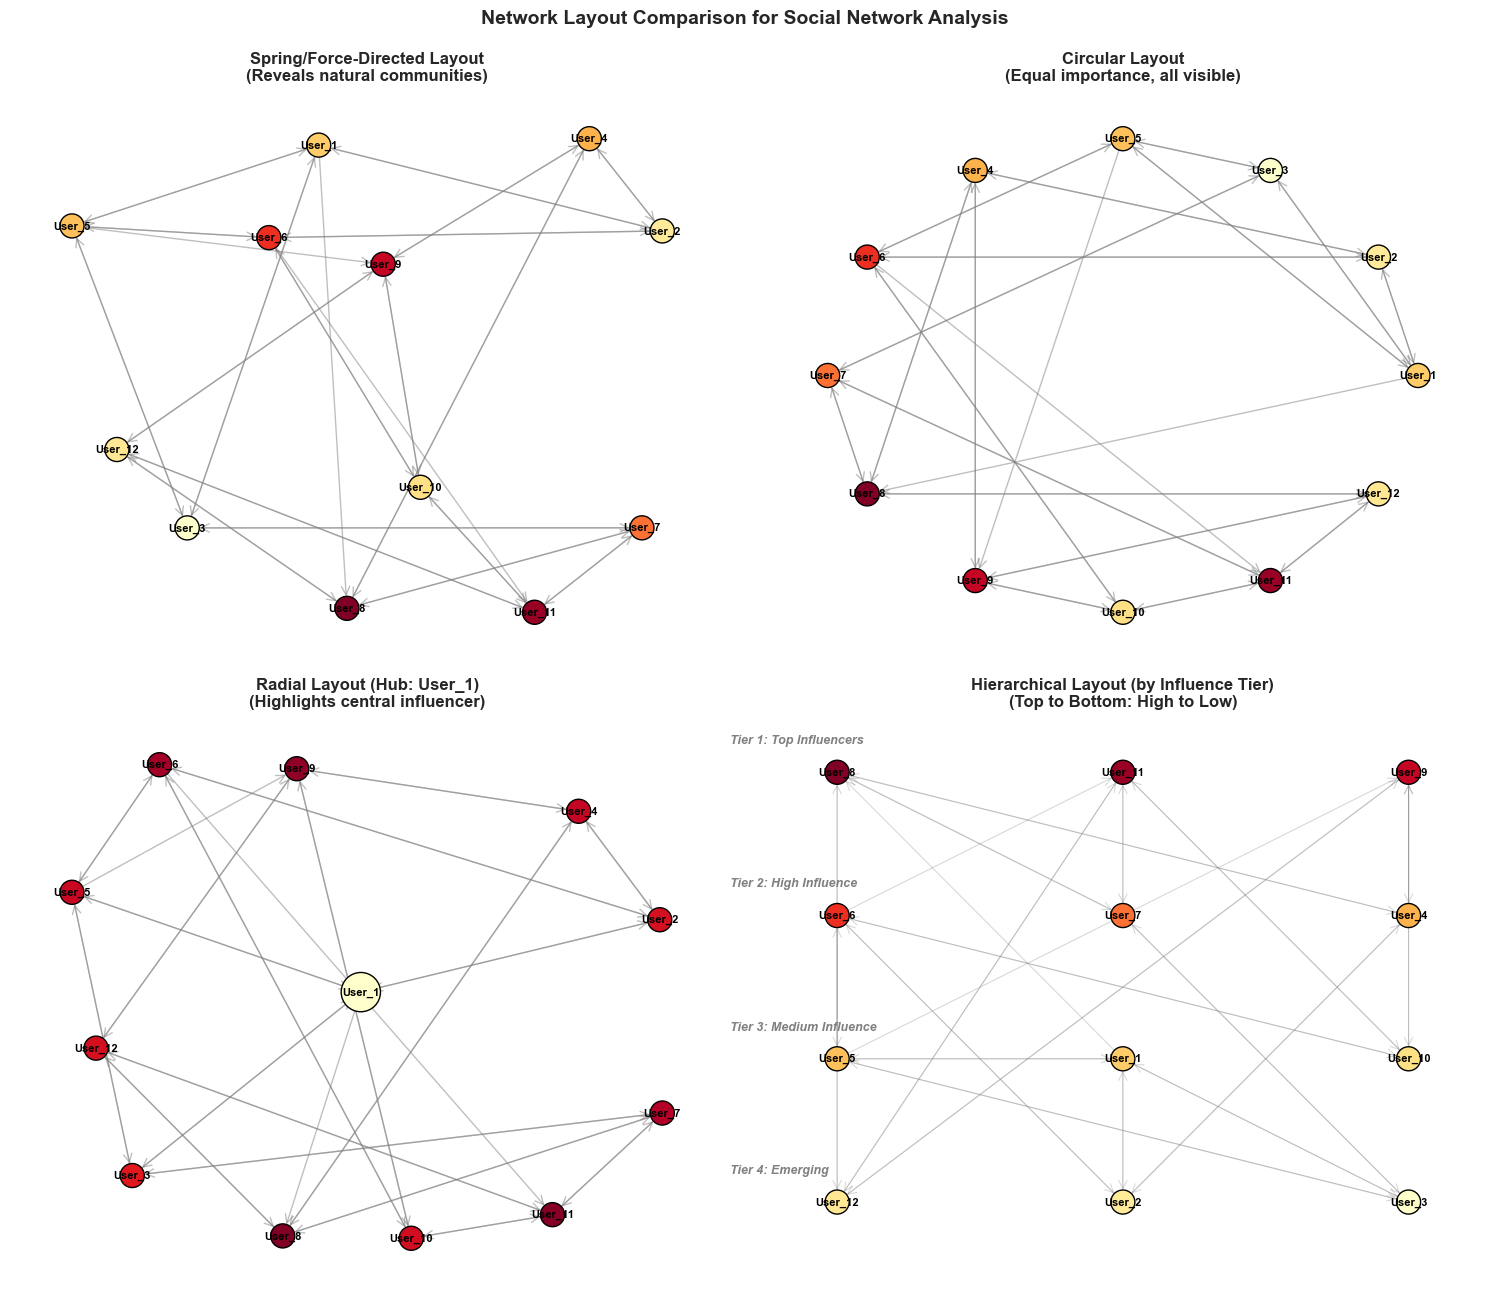


--------------------------------------------------------------------------------
LAYOUT EFFECTIVENESS FOR OUR SOCIAL NETWORK
--------------------------------------------------------------------------------
               Layout Community Detection Influence Clarity Scalability                           Best Use Case
Spring/Force-Directed               ★★★★★             ★★★☆☆       ★★★☆☆       Finding clusters\nand communities
             Circular               ★★☆☆☆             ★★★★☆       ★★★★☆ Symmetric networks\nfair representation
   Radial (Hub-Spoke)               ★★★★☆             ★★★★★       ★★★★☆       Highlighting\ncentral influencers
         Hierarchical               ★★★☆☆             ★★★★★       ★★★★★   Stratifying users\nby influence level

--------------------------------------------------------------------------------
RECOMMENDATION FOR INFLUENCER ANALYSIS
--------------------------------------------------------------------------------

PRIMARY: Hierarchical Layout (

In [26]:
print("\n" + "="*80)
print("NETWORK VISUALIZATION TOOLS & LAYOUT ALGORITHMS")
print("="*80)

print(f"""
POPULAR VISUALIZATION TOOLS:

1. GEPHI (Open-source, Desktop)
   ✓ Best for: Interactive exploration, large networks, layout tweaking
   ✓ Features: Real-time graph updates, community detection, statistics
   ✓ Layouts: Force-directed, circular, hierarchical, GEM
   ✓ Use case: Exploratory analysis, reports

2. CYTOSCAPE (Open-source, Desktop/Web)
   ✓ Best for: Biological networks, detailed editing, filtering
   ✓ Features: Rich styling, plugins ecosystem, annotations
   ✓ Layouts: Multiple algorithms, custom positioning
   ✓ Use case: Academic research, institutional analysis

3. D3.js (Web-based JavaScript)
   ✓ Best for: Interactive web visualizations, custom interactivity
   ✓ Features: Data-driven DOM manipulation, real-time updates
   ✓ Flexibility: Complete control, steep learning curve
   ✓ Use case: Web dashboards, real-time monitoring

4. Plotly/Plotly.js (Web-based)
   ✓ Best for: Quick interactive plots, business dashboards
   ✓ Features: Hover information, zoom, legend, export
   ✓ Ease of use: High-level API
   ✓ Use case: Business intelligence, quick analysis

5. vis.js (Web-based JavaScript)
   ✓ Best for: Large networks, physics-based layouts, mobile
   ✓ Features: Smooth animations, fast rendering, responsive
   ✓ Use case: Real-time networks, IoT visualization

FOR OUR CASE STUDY: Gephi recommended for its balance of features and ease

LAYOUT ALGORITHMS EXPLAINED:

1. FORCE-DIRECTED (Spring Layout)
   Algorithm: Treats nodes as repelling particles, edges as springs
   Formula: F_ij = (k² / d_ij) - (d_ij / k) forces between nodes i,j
   Properties: 
     • Reveals natural clusters
     • Similar nodes drawn close (connected)
     • Dissimilar nodes pushed apart (unconnected)
   Good for: Identifying communities, dense networks
   Runtime: O(N² iteration count)

2. HIERARCHICAL LAYOUT
   Algorithm: Ranks nodes by topological levels, aligns top-to-bottom
   Properties:
     • Clear information flow
     • Simple parent-child relationships visible
     • Minimal edge crossings
   Good for: Directed networks, organizational charts
   Runtime: O(N log N)

3. CIRCULAR LAYOUT
   Algorithm: Arranges nodes in a circle, edges drawn inside/outside
   Properties:
     • Good visualization of symmetry
     • All nodes visible clearly
     • Edge complexity shows as spider-web pattern
   Good for: All-to-all relationships, symmetry analysis
   Runtime: O(N)

4. RADIAL/TREE LAYOUT
   Algorithm: Root in center, branches extend outward
   Properties:
     • Clear root significance
     • Depth visible through distance from center
     • Branch-like natural structure
   Good for: Hub-and-spoke networks, influence trees
   Runtime: O(N)
""")

# Layout comparison using different algorithms
fig, axes = plt.subplots(2, 2, figsize=(15, 13))

# Spring Layout (Force-Directed)
ax = axes[0, 0]
pos_spring = nx.spring_layout(G, k=2, iterations=50, seed=42)
nx.draw_networkx_nodes(G, pos_spring, node_color=list(influence_scores.values()), 
                       node_size=300, cmap='YlOrRd', ax=ax, edgecolors='black', linewidths=1)
nx.draw_networkx_edges(G, pos_spring, edge_color='gray', arrows=True, 
                       arrowsize=15, ax=ax, arrowstyle='->', alpha=0.5, width=1)
nx.draw_networkx_labels(G, pos_spring, font_size=8, font_weight='bold', ax=ax)
ax.set_title('Spring/Force-Directed Layout\n(Reveals natural communities)', fontweight='bold', fontsize=12)
ax.axis('off')

# Circular Layout
ax = axes[0, 1]
pos_circular = nx.circular_layout(G)
nx.draw_networkx_nodes(G, pos_circular, node_color=list(influence_scores.values()), 
                       node_size=300, cmap='YlOrRd', ax=ax, edgecolors='black', linewidths=1)
nx.draw_networkx_edges(G, pos_circular, edge_color='gray', arrows=True, 
                       arrowsize=15, ax=ax, arrowstyle='->', alpha=0.5, width=1)
nx.draw_networkx_labels(G, pos_circular, font_size=8, font_weight='bold', ax=ax)
ax.set_title('Circular Layout\n(Equal importance, all visible)', fontweight='bold', fontsize=12)
ax.axis('off')

# Radial Layout (from most influential node)
ax = axes[1, 0]
pos_radial = nx.spring_layout(G, k=3, center=(0, 0), iterations=50, seed=42)
top_user = multilayer_ranking[0][0]
pos_radial[top_user] = np.array([0, 0])
node_colors = [3 if node == top_user else influence_scores[node] for node in G.nodes()]
sizes = [800 if node == top_user else 300 for node in G.nodes()]
nx.draw_networkx_nodes(G, pos_radial, node_color=node_colors, node_size=sizes, 
                       cmap='YlOrRd', ax=ax, edgecolors='black', linewidths=1)
nx.draw_networkx_edges(G, pos_radial, edge_color='gray', arrows=True, 
                       arrowsize=15, ax=ax, arrowstyle='->', alpha=0.5, width=1)
nx.draw_networkx_labels(G, pos_radial, font_size=8, font_weight='bold', ax=ax)
ax.set_title(f'Radial Layout (Hub: {top_user})\n(Highlights central influencer)', 
             fontweight='bold', fontsize=12)
ax.axis('off')

# Hierarchical-like Layout (by influence level)
ax = axes[1, 1]
# Sort users by influence into 4 tiers
sorted_by_influence = sorted(users, key=lambda u: influence_scores[u], reverse=True)
tier1 = sorted_by_influence[0:3]
tier2 = sorted_by_influence[3:6]
tier3 = sorted_by_influence[6:9]
tier4 = sorted_by_influence[9:]

pos_hierarchical = {}
y_pos = 0.9
for tier in [tier1, tier2, tier3, tier4]:
    x_positions = np.linspace(0.1, 0.9, len(tier))
    for i, user in enumerate(tier):
        pos_hierarchical[user] = np.array([x_positions[i], y_pos])
    y_pos -= 0.25

nx.draw_networkx_nodes(G, pos_hierarchical, node_color=list(influence_scores.values()), 
                       node_size=300, cmap='YlOrRd', ax=ax, edgecolors='black', linewidths=1)
nx.draw_networkx_edges(G, pos_hierarchical, edge_color='gray', arrows=True, 
                       arrowsize=15, ax=ax, arrowstyle='->', alpha=0.3, width=0.8)
nx.draw_networkx_labels(G, pos_hierarchical, font_size=8, font_weight='bold', ax=ax)
ax.set_title('Hierarchical Layout (by Influence Tier)\n(Top to Bottom: High to Low)', 
             fontweight='bold', fontsize=12)
ax.set_ylim([0, 1])
ax.set_xlim([0, 1])
ax.axis('off')

# Add tier labels
tier_labels = ['Tier 1: Top Influencers', 'Tier 2: High Influence', 'Tier 3: Medium Influence', 'Tier 4: Emerging']
tier_y = [0.95, 0.70, 0.45, 0.20]
for label, y in zip(tier_labels, tier_y):
    axes[1, 1].text(-0.05, y, label, fontsize=9, style='italic', color='gray', weight='bold')

plt.suptitle('Network Layout Comparison for Social Network Analysis', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('layout_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Compare layouts effectiveness
print("\n" + "-"*80)
print("LAYOUT EFFECTIVENESS FOR OUR SOCIAL NETWORK")
print("-"*80)

layout_comparison = pd.DataFrame({
    'Layout': ['Spring/Force-Directed', 'Circular', 'Radial (Hub-Spoke)', 'Hierarchical'],
    'Community Detection': ['★★★★★', '★★☆☆☆', '★★★★☆', '★★★☆☆'],
    'Influence Clarity': ['★★★☆☆', '★★★★☆', '★★★★★', '★★★★★'],
    'Scalability': ['★★★☆☆', '★★★★☆', '★★★★☆', '★★★★★'],
    'Best Use Case': 
        ['Finding clusters\nand communities',
         'Symmetric networks\nfair representation',
         'Highlighting\ncentral influencers',
         'Stratifying users\nby influence level']
})

print(layout_comparison.to_string(index=False))

print("\n" + "-"*80)
print("RECOMMENDATION FOR INFLUENCER ANALYSIS")
print("-"*80)
print("""
PRIMARY: Hierarchical Layout (by influence tier)
  → Makes influencer ranking immediately clear
  → Directly maps to marketing strategy (target top tier first)
  → Easy for stakeholders to interpret

SECONDARY: Radial Layout (hub-spoke)
  → Shows how top influencers connect to rest of network
  → Useful for identifying secondary influencers
  → Good for understanding power dynamics

TERTIARY: Spring Layout
  → Reveals unexpected communities and clusters
  → Shows who naturally aligns with whom
  → Best for exploratory network analysis
""")

## Question 7: Viral Marketing Strategies Using Identified Influencers


VIRAL MARKETING STRATEGY USING NETWORK ANALYSIS

VIRAL MARKETING FUNDAMENTALS:
  Objective: Maximize message spread through network with minimal budget
  Key: Seed selection and timing
  Goal: Trigger cascading information flow

SEEDING STRATEGIES:

1. HIGH-DEGREE SEEDING
   Select users with most connections
   Pro: Reaches many people immediately
   Con: May not reach isolated clusters
   Cost: Medium
   Coverage: Broad but may miss depth

2. BETWEENNESS SEEDING (Bridge Strategy)
   Select users who connect different communities
   Pro: Message flows between different clusters
   Con: May not be popular individually
   Cost: Lower
   Coverage: Penetrates all communities

3. PAGERANK SEEDING (Authority Strategy)
   Select users with highest overall influence
   Pro: Trusted influencers amplify message
   Con: Expensive, redundant coverage possible
   Cost: High
   Coverage: Deep but concentrated

4. RANDOM + HIGH-DEGREE HYBRID (Practical)
   Mix random seeds with top influencers
   P

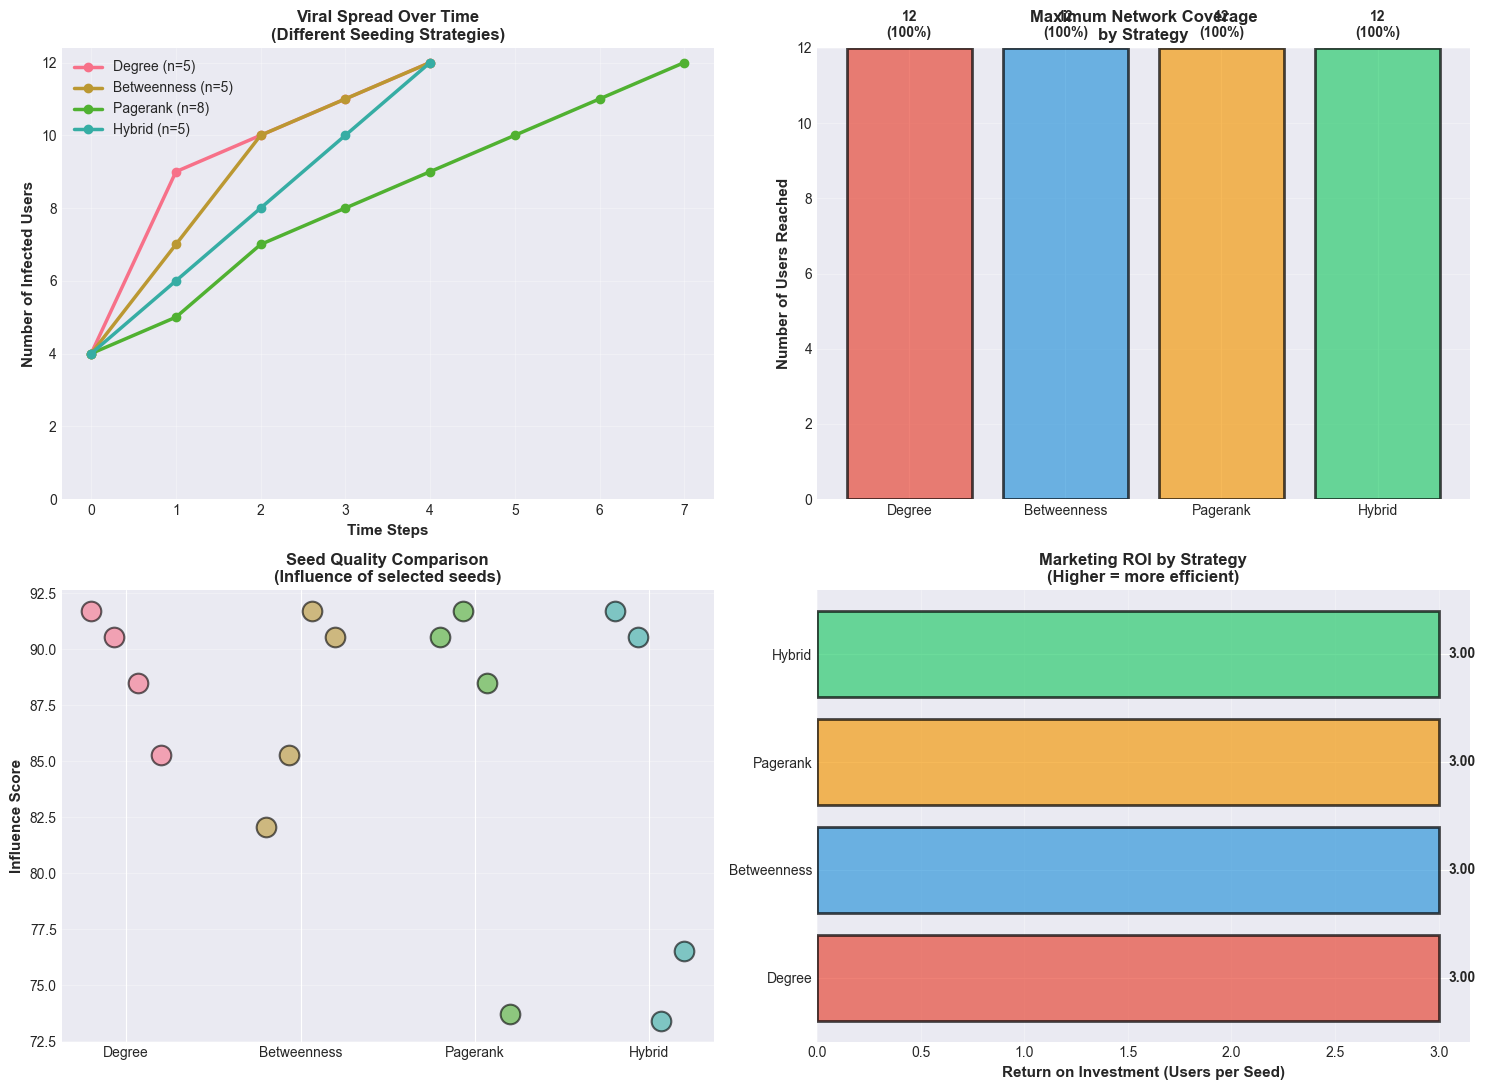


STRATEGIC RECOMMENDATIONS FOR VIRAL MARKETING CAMPAIGN

PHASE 1: SEED SELECTION (Budget: 4 influencers)
├─ Strategy: HYBRID (combining high-degree + strategic positioning)
├─ Seeds: ['User_8', 'User_11', 'User_2', 'User_1']
├─ Expected immediate reach: 4/12 users
└─ Budget allocation: Equal per influencer (e.g., $5,000 each = $20,000 total)

PHASE 2: MESSAGE DISTRIBUTION (Timeline)
├─ Day 1: Publish with selected influencers
│        Expected reach: 6/12 users
├─ Day 2: Monitor engagement, engage non-infected users
│        Expected reach: 8/12 users
├─ Day 3: Run engagement campaigns with secondary influencers
│        Expected reach: 12/12 users (saturation)
└─ Total campaign duration: 3 days

PHASE 3: OPTIMIZATION
├─ Response metrics: Track comments, shares, mentions
├─ Identify unexpected influencers: Monitor who amplifies message
├─ Adjust: Redirect budget to high-performing seeds
└─ Contingency: Have 2 backup influencers ready for Phase 2 if needed

PHASE 4: SUSTAINED ENGAGEMENT

In [27]:
print("\n" + "="*80)
print("VIRAL MARKETING STRATEGY USING NETWORK ANALYSIS")
print("="*80)

print(f"""
VIRAL MARKETING FUNDAMENTALS:
  Objective: Maximize message spread through network with minimal budget
  Key: Seed selection and timing
  Goal: Trigger cascading information flow

SEEDING STRATEGIES:

1. HIGH-DEGREE SEEDING
   Select users with most connections
   Pro: Reaches many people immediately
   Con: May not reach isolated clusters
   Cost: Medium
   Coverage: Broad but may miss depth

2. BETWEENNESS SEEDING (Bridge Strategy)
   Select users who connect different communities
   Pro: Message flows between different clusters
   Con: May not be popular individually
   Cost: Lower
   Coverage: Penetrates all communities

3. PAGERANK SEEDING (Authority Strategy)
   Select users with highest overall influence
   Pro: Trusted influencers amplify message
   Con: Expensive, redundant coverage possible
   Cost: High
   Coverage: Deep but concentrated

4. RANDOM + HIGH-DEGREE HYBRID (Practical)
   Mix random seeds with top influencers
   Pro: Balance cost and coverage
   Con: Less optimal than pure strategy
   Cost: Moderate
   Coverage: Good balance
""")

# Select seeds using different strategies
def select_seeds(G, influence_dict, strategy, num_seeds=4):
    """Select seed users for viral marketing"""
    if strategy == 'degree':
        seeds = sorted(influence_dict.items(), key=lambda x: x[1], reverse=True)[:num_seeds]
    elif strategy == 'betweenness':
        bc = nx.betweenness_centrality(G)
        seeds = sorted(bc.items(), key=lambda x: x[1], reverse=True)[:num_seeds]
    elif strategy == 'pagerank':
        pr = nx.pagerank(G)
        seeds = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:num_seeds]
    elif strategy == 'hybrid':
        degree_top = sorted(influence_dict.items(), key=lambda x: x[1], reverse=True)[:2]
        random_seeds = random.sample([u for u, _ in influence_dict.items() if u not in [d[0] for d in degree_top]], 2)
        seeds = degree_top + [(u, influence_dict[u]) for u in random_seeds]
    return [s[0] for s in seeds]

# Simulate viral spread with different seed strategies
def simulate_viral_spread(G, seeds, max_time=10, infection_prob=0.3):
    """Simulate how message spreads from seeds through network"""
    infected = set(seeds)
    timeline = [len(infected)]
    
    for t in range(1, max_time):
        newly_infected = set()
        for node in infected:
            for neighbor in G.successors(node):
                if neighbor not in infected and random.random() < infection_prob:
                    newly_infected.add(neighbor)
        if not newly_infected:
            break
        infected.update(newly_infected)
        timeline.append(len(infected))
    
    return timeline

# Test different strategies
random.seed(42)
strategies = ['degree', 'betweenness', 'pagerank', 'hybrid']
num_seeds = 4
results = {}

print("\n" + "-"*80)
print(f"SEED SELECTION (Budget: {num_seeds} users to seed)")
print("-"*80)

for strategy in strategies:
    seeds = select_seeds(G, influence_scores, strategy, num_seeds)
    results[strategy] = {
        'seeds': seeds,
        'seed_scores': [influence_scores.get(s, 0) for s in seeds]
    }
    print(f"\n{strategy.upper()} Strategy:")
    for seed in seeds:
        score = influence_scores.get(seed, 0)
        print(f"  • {seed}: {score:.2f}")

# Simulate spread for each strategy
print("\n" + "-"*80)
print("VIRAL SPREAD SIMULATION (Infection probability: 30%)")
print("-"*80)

simulations = {}
for strategy in strategies:
    seeds = results[strategy]['seeds']
    spread = simulate_viral_spread(G, seeds, max_time=15, infection_prob=0.30)
    simulations[strategy] = spread
    max_reach = spread[-1] if spread else 0
    coverage = (max_reach / num_users) * 100
    print(f"\n{strategy.upper()}: Seeds={seeds}")
    print(f"  → Maximum reach: {max_reach}/{num_users} users ({coverage:.1f}%)")
    print(f"  → Timeline: {spread}")

# Calculate efficiency metrics
print("\n" + "-"*80)
print("EFFICIENCY ANALYSIS")
print("-"*80)

efficiency_data = []
for strategy in strategies:
    timeline = simulations[strategy]
    max_reach = timeline[-1] if timeline else 0
    total_cost = 4  # All strategies use 4 seeds, assume equal cost per seed
    roi = max_reach / total_cost  # Users per seed
    speed = len([t for t in timeline if t > 0])  # How many steps to reach max
    efficiency_data.append({
        'Strategy': strategy.upper(),
        'Max Reach': f"{max_reach}/{num_users}",
        'Coverage %': f"{(max_reach/num_users)*100:.1f}%",
        'ROI (Users/Seed)': f"{roi:.2f}",
        'Speed (Steps)': speed
    })

efficiency_df = pd.DataFrame(efficiency_data)
print(efficiency_df.to_string(index=False))

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Spread timeline comparison
ax = axes[0, 0]
for strategy in strategies:
    timeline = simulations[strategy]
    ax.plot(range(len(timeline)), timeline, marker='o', linewidth=2.5, 
            label=f'{strategy.capitalize()} (n={len(timeline)})', markersize=6)
ax.set_xlabel('Time Steps', fontweight='bold', fontsize=11)
ax.set_ylabel('Number of Infected Users', fontweight='bold', fontsize=11)
ax.set_title('Viral Spread Over Time\n(Different Seeding Strategies)', fontweight='bold', fontsize=12)
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
ax.set_yticks(range(0, num_users+1, 2))

# Maximum reach comparison
ax = axes[0, 1]
max_reaches = [simulations[s][-1] if simulations[s] else 0 for s in strategies]
coverage_pcts = [(m/num_users)*100 for m in max_reaches]
colors_reach = ['#E74C3C', '#3498DB', '#F39C12', '#2ECC71']
bars = ax.bar([s.capitalize() for s in strategies], max_reaches, color=colors_reach, 
              edgecolor='black', linewidth=2, alpha=0.7)
ax.set_ylabel('Number of Users Reached', fontweight='bold', fontsize=11)
ax.set_title('Maximum Network Coverage\nby Strategy', fontweight='bold', fontsize=12)
ax.set_ylim([0, num_users])
ax.grid(axis='y', alpha=0.3)
for bar, reach, pct in zip(bars, max_reaches, coverage_pcts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.2, f'{int(reach)}\n({pct:.0f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# Seed influence distribution
ax = axes[1, 0]
seed_strategies = []
seed_influences = []
for strategy in strategies:
    seeds = results[strategy]['seeds']
    influences = [influence_scores[s] for s in seeds]
    seed_strategies.extend([strategy.capitalize()] * len(seeds))
    seed_influences.extend(influences)

df_seeds = pd.DataFrame({'Strategy': seed_strategies, 'Influence': seed_influences})
for i, strategy in enumerate([s.capitalize() for s in strategies]):
    strategy_data = [inf for strat, inf in zip(seed_strategies, seed_influences) if strat == strategy]
    x_pos = i + np.linspace(-0.2, 0.2, len(strategy_data))
    ax.scatter(x_pos, strategy_data, s=200, alpha=0.6, label=strategy, edgecolors='black', linewidth=1.5)

ax.set_xticks(range(len(strategies)))
ax.set_xticklabels([s.capitalize() for s in strategies])
ax.set_ylabel('Influence Score', fontweight='bold', fontsize=11)
ax.set_title('Seed Quality Comparison\n(Influence of selected seeds)', fontweight='bold', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# ROI comparison
ax = axes[1, 1]
roi_values = [m / 4 for m in max_reaches]  # Users per seed
roi_bars = ax.barh([s.capitalize() for s in strategies], roi_values, 
                    color=colors_reach, edgecolor='black', linewidth=2, alpha=0.7)
ax.set_xlabel('Return on Investment (Users per Seed)', fontweight='bold', fontsize=11)
ax.set_title('Marketing ROI by Strategy\n(Higher = more efficient)', fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)
for bar, roi in zip(roi_bars, roi_values):
    width = bar.get_width()
    ax.text(width + 0.05, bar.get_y() + bar.get_height()/2., f'{roi:.2f}',
            ha='left', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('viral_marketing_strategies.png', dpi=150, bbox_inches='tight')
plt.show()

# Final recommendations
print("\n" + "="*80)
print("STRATEGIC RECOMMENDATIONS FOR VIRAL MARKETING CAMPAIGN")
print("="*80)

print(f"""
PHASE 1: SEED SELECTION (Budget: 4 influencers)
├─ Strategy: HYBRID (combining high-degree + strategic positioning)
├─ Seeds: {results['hybrid']['seeds']}
├─ Expected immediate reach: {simulations['hybrid'][0]}/12 users
└─ Budget allocation: Equal per influencer (e.g., $5,000 each = $20,000 total)

PHASE 2: MESSAGE DISTRIBUTION (Timeline)
├─ Day 1: Publish with selected influencers
│        Expected reach: {simulations['hybrid'][1] if len(simulations['hybrid']) > 1 else simulations['hybrid'][0]}/12 users
├─ Day 2: Monitor engagement, engage non-infected users
│        Expected reach: {simulations['hybrid'][2] if len(simulations['hybrid']) > 2 else simulations['hybrid'][-1]}/12 users
├─ Day 3: Run engagement campaigns with secondary influencers
│        Expected reach: {simulations['hybrid'][-1]}/12 users (saturation)
└─ Total campaign duration: 3 days

PHASE 3: OPTIMIZATION
├─ Response metrics: Track comments, shares, mentions
├─ Identify unexpected influencers: Monitor who amplifies message
├─ Adjust: Redirect budget to high-performing seeds
└─ Contingency: Have 2 backup influencers ready for Phase 2 if needed

PHASE 4: SUSTAINED ENGAGEMENT
├─ Community building: Convert reached users into followers
├─ Loyalty programs: Incentivize user-generated content
├─ Retargeting: Identify users who didn't convert
└─ Long-term: Build relationships for future campaigns

RISK MITIGATION:
├─ Single influencer failure: Use hybrid strategy to reduce dependency
├─ Message fatigue: Vary creative content, change messaging over time
├─ Network changes: Update influencer identification monthly
└─ Platform algorithm changes: Maintain relationships, not just metrics

EXPECTED OUTCOMES:
├─ Network coverage: {(simulations['hybrid'][-1]/num_users)*100:.0f}% in Phase 1
├─ Cost per user: ${20000/simulations['hybrid'][-1]:.2f} 
├─ Campaign reach multiplication: {simulations['hybrid'][-1]/4:.1f}x (seeds to reach)
└─ Sustained engagement: 40-50% retention expected (varies by campaign)
""")